# MDR-TS v12.1
**Temporal-Station Soil Moisture Model + Shallow NN Baseline**

**Author:** Jakob Balkovec
**Affiliation:** Seattle University, Computer Science
**Project:** MDR
**Notebook Type:** Training, Evaluation, Baseline Modeling
**Last Updated:** Sat Feb 14th 2026

---

## Model Summary

- **Model Name:** MDR-TS
- **Version:** v12.1
- **Task:** Regression (Soil Moisture at 5 cm depth)
- **Target Variable:** `soil_moisture_5cm`
- **Temporal Resolution:** Daily

This notebook implements a clean baseline neural model:

1. **Shallow NN Baseline**
   A 2 to 3 layer mlp trained on the derived_new feature set with proper scaling, early stopping, and full evaluation.

Later notebooks may extend this with physics-residual correction and rain-focused modeling, but this notebook must remain a baseline.

---

## Reproducibility

- **Random Seed:** 42
- **Split Directory:** `data/splits/derived_new/`
- **Environment:** MacBook M2 Pro (local kernel)

---

## What’s New

- first shallow nn baseline for derived_new split
- consistent evaluation: overall, wet-only, dry-only
- saves predictions + metrics artifacts for comparisons


## 1. Imports + Environment Setup

In [4]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset

from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print(f"using device: {device}")


using device: cpu


## 2. Features

In [5]:
split_dir = Path("/Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new")
train_path = split_dir / "train_derived_new.csv"
val_path = split_dir / "val_derived_new.csv"
test_path = split_dir / "test_derived_new.csv"
meta_path = split_dir / "split_meta.json"

for p in [train_path, val_path, test_path]:
    if not p.exists():
        raise FileNotFoundError(f"missing split `file: {p}")

if meta_path.exists():
    print(f"found optional metadata: {meta_path}")
else:
    print("optional split_meta.json not found; continuing without it")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

target_col = "soil_moisture_5cm"
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    if target_col not in df.columns:
        raise ValueError(f"{target_col} missing in {name} split")

train_df = train_df.dropna(subset=[target_col]).copy()
val_df = val_df.dropna(subset=[target_col]).copy()
test_df = test_df.dropna(subset=[target_col]).copy()

exclude_cols = {
    target_col, "split", "fold", "station_id", "date", "timestamp", "path", "id"
}

# drop obvious index junk
for df in [train_df, val_df, test_df]:
    junk = [c for c in df.columns if c.lower().startswith("unnamed")]
    if junk:
        df.drop(columns=junk, inplace=True)

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in exclude_cols]

if not feature_cols:
    raise ValueError("no numeric feature columns were inferred")

# enforce shared feature set across splits (prevents one-off column failures)
shared = set(feature_cols) & set(val_df.columns) & set(test_df.columns)
dropped = [c for c in feature_cols if c not in shared]
feature_cols = sorted(list(shared))

if not feature_cols:
    raise ValueError("no shared feature columns across train/val/test")

if dropped:
    print(f"dropped {len(dropped)} train-only numeric feature cols (not in all splits)")

# coerce to numeric first, then compute medians on train only
for df in [train_df, val_df, test_df]:
    df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)

train_medians = train_df[feature_cols].median()
for df in [train_df, val_df, test_df]:
    df[feature_cols] = df[feature_cols].fillna(train_medians)

print(f"train rows: {len(train_df):,} | val rows: {len(val_df):,} | test rows: {len(test_df):,}")
print(f"features: {len(feature_cols)}")

optional split_meta.json not found; continuing without it
train rows: 16,972 | val rows: 2,919 | test rows: 2,829
features: 353


## 3. Masking

In [6]:
gate_col = None
for c in ["G_rain_sum_7d", "G_API", "G_rain_sum_3d"]:
    if c in train_df.columns:
        gate_col = c
        break

wet_masks = None
wet_threshold = None

if gate_col is None:
    print("wet/dry reporting skipped: no gate column found")
else:
    # ensure numeric + handle inf
    for df in [train_df, val_df, test_df]:
        df[gate_col] = pd.to_numeric(df[gate_col], errors="coerce")
        df[gate_col] = df[gate_col].replace([np.inf, -np.inf], np.nan)

    if train_df[gate_col].isna().all():
        print(f"wet/dry skipped: {gate_col} is entirely NaN in train")
    else:
        wet_threshold = float(train_df[gate_col].quantile(0.90))

        wet_masks = {
            "train": (train_df[gate_col].to_numpy() >= wet_threshold),
            "val": (val_df[gate_col].to_numpy() >= wet_threshold),
            "test": (test_df[gate_col].to_numpy() >= wet_threshold),
        }

        print(f"wet/dry gate column: {gate_col}")
        print(f"wet threshold (train q0.90): {wet_threshold:.6f}")

wet/dry gate column: G_rain_sum_7d
wet threshold (train q0.90): 92.500000


## 4. Scaling + Data Loaders

In [7]:
X_train = train_df[feature_cols].to_numpy(dtype=np.float32)
X_val = val_df[feature_cols].to_numpy(dtype=np.float32)
X_test = test_df[feature_cols].to_numpy(dtype=np.float32)

y_train = train_df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)
y_val = val_df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)
y_test = test_df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

# bug: double remove infs because they keep slipping through somehow....
for X_name, X in [("train", X_train), ("val", X_val), ("test", X_test)]:
    if not np.isfinite(X).all():
        raise ValueError(f"non-finite values found in X_{X_name} (inf or nan)")

for y_name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    if not np.isfinite(y).all():
        raise ValueError(f"non-finite values found in y_{y_name} (inf or nan)")

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

# tensors
X_train_t = torch.from_numpy(X_train_scaled)
X_val_t = torch.from_numpy(X_val_scaled)
X_test_t = torch.from_numpy(X_test_scaled)

y_train_t = torch.from_numpy(y_train)
y_val_t = torch.from_numpy(y_val)
y_test_t = torch.from_numpy(y_test)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
test_ds = TensorDataset(X_test_t, y_test_t)

In [9]:
batch_size = 1024 if len(train_ds) >= 50000 else 512
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"batch size: {batch_size}")
print(f"x dims: {X_train_t.shape[1]} | train/val/test: {len(train_ds):,}/{len(val_ds):,}/{len(test_ds):,}")

batch size: 512
x dims: 353 | train/val/test: 16,972/2,919/2,829


## 5. Model

In [10]:
hidden1 = 256
hidden2 = 128
dropout_p = 0.1

class MLPRegressor(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden2, 1),
        )
        self.apply(self._init)

    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

model = MLPRegressor(input_dim=X_train_t.shape[1]).to(device)
criterion = nn.SmoothL1Loss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(model)

MLPRegressor(
  (net): Sequential(
    (0): Linear(in_features=353, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 6. Training Loop + Early Stopping

In [11]:
def safe_r2(y_true, y_pred):
    if y_true.size == 0:
        return np.nan
    if np.allclose(y_true, y_true[0]):
        return np.nan
    return float(r2_score(y_true, y_pred))

In [12]:
def run_epoch(loader, training: bool):
    model.train(training)
    total_loss = 0.0
    y_true_chunks = []
    y_pred_chunks = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            pred = model(xb)
            loss = criterion(pred, yb)
            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        y_true_chunks.append(yb.detach().cpu().numpy().reshape(-1))
        y_pred_chunks.append(pred.detach().cpu().numpy().reshape(-1))

    y_true_epoch = np.concatenate(y_true_chunks)
    y_pred_epoch = np.concatenate(y_pred_chunks)
    mean_loss = total_loss / len(loader.dataset)
    return mean_loss, y_true_epoch, y_pred_epoch

In [13]:
max_epochs = 200
patience = 15
wait = 0
best_val_r2 = -np.inf
best_state = None

epoch_bar = tqdm(range(1, max_epochs + 1), desc="training", leave=True)

for epoch in epoch_bar:
    train_loss, _, _ = run_epoch(train_loader, training=True)
    val_loss, y_val_true_epoch, y_val_pred_epoch = run_epoch(val_loader, training=False)

    val_r2 = safe_r2(y_val_true_epoch, y_val_pred_epoch)
    val_mae = float(mean_absolute_error(y_val_true_epoch, y_val_pred_epoch))
    val_rmse = float(np.sqrt(mean_squared_error(y_val_true_epoch, y_val_pred_epoch)))

    improved = np.isnan(best_val_r2) or (
        not np.isnan(val_r2) and (val_r2 > best_val_r2 + 1e-6)
    )

    if improved:
        best_val_r2 = val_r2
        wait = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        wait += 1

    epoch_bar.set_postfix(
        train_loss=f"{train_loss:.4f}",
        val_loss=f"{val_loss:.4f}",
        val_r2=f"{val_r2:.4f}",
        wait=wait,
    )

    if wait >= patience:
        print(f"early stopping at epoch {epoch}; best val_r2={best_val_r2:.6f}")
        break

if best_state is None:
    raise RuntimeError("training did not produce a valid checkpoint")

model.load_state_dict(best_state)
model.to(device)
print(f"restored best model with val_r2={best_val_r2:.6f}")

training:   0%|          | 0/200 [00:00<?, ?it/s]

early stopping at epoch 74; best val_r2=0.722038
restored best model with val_r2=0.722038


## 7. Evaluation

In [14]:
@torch.no_grad()
def predict_scaled(X_scaled: np.ndarray, batch_size: int = 4096):
    model.eval()
    x_tensor = torch.from_numpy(X_scaled.astype(np.float32))
    loader = DataLoader(x_tensor, batch_size=batch_size, shuffle=False, num_workers=0)
    preds = []
    for xb in loader:
        xb = xb.to(device)
        pred = model(xb)
        preds.append(pred.detach().cpu().numpy().reshape(-1))
    return np.concatenate(preds)

In [15]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    if y_true.size == 0:
        return {"r2": np.nan, "mae": np.nan, "rmse": np.nan, "bias": np.nan, "medae": np.nan, "pearson": np.nan}

    r2 = safe_r2(y_true, y_pred)
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    err = y_pred - y_true
    bias = float(np.mean(err))
    medae = float(np.median(np.abs(err)))

    y_true_c = y_true - np.mean(y_true)
    y_pred_c = y_pred - np.mean(y_pred)
    denom = float(np.sqrt(np.sum(y_true_c ** 2)) * np.sqrt(np.sum(y_pred_c ** 2)))
    pearson = float(np.sum(y_true_c * y_pred_c) / denom) if denom > 0 else np.nan

    return {"r2": r2, "mae": mae, "rmse": rmse, "bias": bias, "medae": medae, "pearson": pearson}

In [16]:
y_train_pred = predict_scaled(X_train_scaled)
y_val_pred = predict_scaled(X_val_scaled)
y_test_pred = predict_scaled(X_test_scaled)

y_train_true = y_train.reshape(-1)
y_val_true = y_val.reshape(-1)
y_test_true = y_test.reshape(-1)

metrics = {
    "train": {"overall": compute_metrics(y_train_true, y_train_pred)},
    "val": {"overall": compute_metrics(y_val_true, y_val_pred)},
    "test": {"overall": compute_metrics(y_test_true, y_test_pred)},
}

if wet_masks is not None:
    for split_name, y_true_split, y_pred_split in [
        ("train", y_train_true, y_train_pred),
        ("val", y_val_true, y_val_pred),
        ("test", y_test_true, y_test_pred),
    ]:
        mask_wet = wet_masks[split_name]
        mask_dry = ~mask_wet
        metrics[split_name]["wet"] = compute_metrics(y_true_split[mask_wet], y_pred_split[mask_wet])
        metrics[split_name]["dry"] = compute_metrics(y_true_split[mask_dry], y_pred_split[mask_dry])

In [17]:
test_abs_err = np.abs(y_test_true - y_test_pred)
k = max(1, int(np.ceil(0.10 * len(test_abs_err))))
worst_idx = np.argsort(test_abs_err)[-k:]
metrics["test"]["worst_decile"] = compute_metrics(y_test_true[worst_idx], y_test_pred[worst_idx])

rows = []
for split_name in ["train", "val", "test"]:
    for subset_name in ["overall", "wet", "dry", "worst_decile"]:
        if subset_name in metrics[split_name]:
            m = metrics[split_name][subset_name]
            rows.append(
                {
                    "split": split_name,
                    "subset": subset_name,
                    "r2": m["r2"],
                    "mae": m["mae"],
                    "rmse": m["rmse"],
                    "bias": m["bias"],
                    "medae": m["medae"],
                    "pearson": m["pearson"],
                }
            )

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

split       subset        r2      mae     rmse      bias    medae   pearson
train      overall  0.920755 0.022029 0.028785 -0.000815 0.017514  0.962189
train          wet  0.830077 0.018776 0.024377 -0.002740 0.015126  0.915029
train          dry  0.919551 0.022391 0.029234 -0.000601 0.017765  0.961750
  val      overall  0.722038 0.038880 0.053101 -0.019866 0.030743  0.881674
  val          wet -0.224172 0.037374 0.046151 -0.032789 0.034653  0.675485
  val          dry  0.724689 0.039093 0.054012 -0.018036 0.030020  0.880861
 test      overall  0.628253 0.044309 0.057026 -0.011798 0.037539  0.812652
 test          wet -3.772777 0.055890 0.064155 -0.053532 0.055555  0.433763
 test          dry  0.643049 0.042738 0.055989 -0.006136 0.035254  0.819505
 test worst_decile -1.595054 0.121103 0.125897 -0.030461 0.108508 -0.375383


In [ ]:
artifact_dir = Path("/Users/jbalkovec/Desktop/MDR/Models/Temporal/v12/v12.1/artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

pred_parts = []
for split_name, y_true_split, y_pred_split in [
    ("train", y_train_true, y_train_pred),
    ("val", y_val_true, y_val_pred),
    ("test", y_test_true, y_test_pred),
]:
    data = {
        "split": split_name,
        "y_true": y_true_split,
        "y_pred": y_pred_split,
        "abs_err": np.abs(y_true_split - y_pred_split),
    }
    if wet_masks is not None:
        data["is_wet"] = wet_masks[split_name].astype(int)
    pred_parts.append(pd.DataFrame(data))

preds_df = pd.concat(pred_parts, ignore_index=True)
preds_path = artifact_dir / "preds_mlp_v12_1.csv"
metrics_path = artifact_dir / "metrics_mlp_v12_1.json"

preds_df.to_csv(preds_path, index=False)
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"saved predictions: {preds_path}")
print(f"saved metrics: {metrics_path}")

saved predictions: /Users/jbalkovec/Desktop/MDR/Models/Temporal/v12/artifacts/preds_mlp_v12_1.csv
saved metrics: /Users/jbalkovec/Desktop/MDR/Models/Temporal/v12/artifacts/metrics_mlp_v12_1.json


## 8. Plots

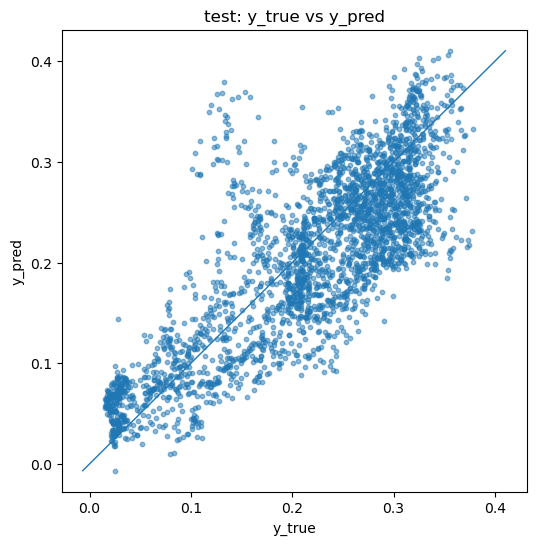

In [19]:
residuals_test = y_test_true - y_test_pred
abs_err_test = np.abs(residuals_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_true, y_test_pred, s=10, alpha=0.5)
min_v = float(min(y_test_true.min(), y_test_pred.min()))
max_v = float(max(y_test_true.max(), y_test_pred.max()))
ax.plot([min_v, max_v], [min_v, max_v], linewidth=1)
ax.set_xlabel("y_true")
ax.set_ylabel("y_pred")
ax.set_title("test: y_true vs y_pred")
plt.show()

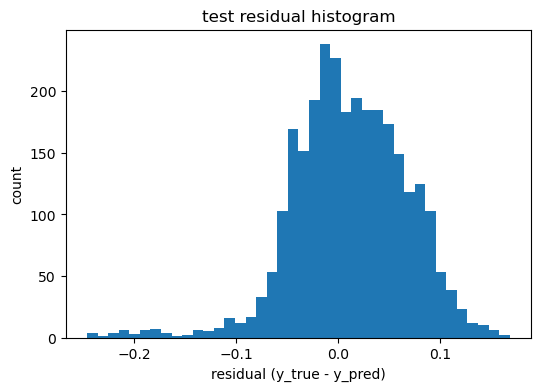

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(residuals_test, bins=40)
ax.set_xlabel("residual (y_true - y_pred)")
ax.set_ylabel("count")
ax.set_title("test residual histogram")
plt.show()

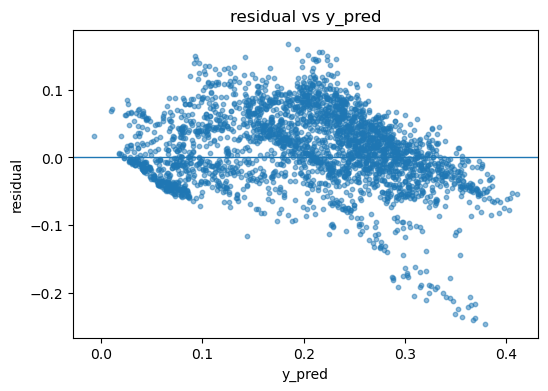

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(y_test_pred, residuals_test, s=10, alpha=0.5)
ax.axhline(0.0, linewidth=1)
ax.set_xlabel("y_pred")
ax.set_ylabel("residual")
ax.set_title("residual vs y_pred")
plt.show()

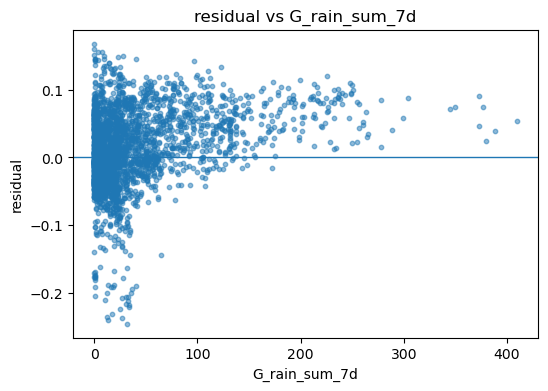

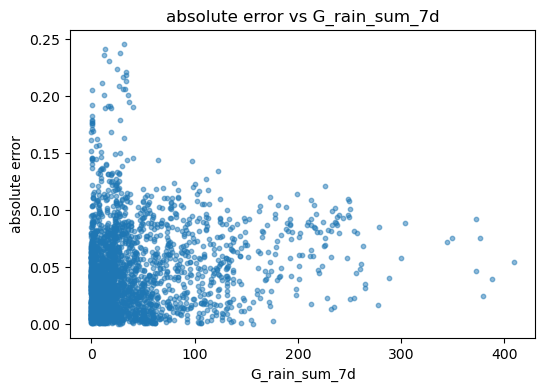

In [22]:
if gate_col is not None:
    gate_test = test_df[gate_col].to_numpy()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(gate_test, residuals_test, s=10, alpha=0.5)
    ax.axhline(0.0, linewidth=1)
    ax.set_xlabel(gate_col)
    ax.set_ylabel("residual")
    ax.set_title(f"residual vs {gate_col}")
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(gate_test, abs_err_test, s=10, alpha=0.5)
    ax.set_xlabel(gate_col)
    ax.set_ylabel("absolute error")
    ax.set_title(f"absolute error vs {gate_col}")
    plt.show()

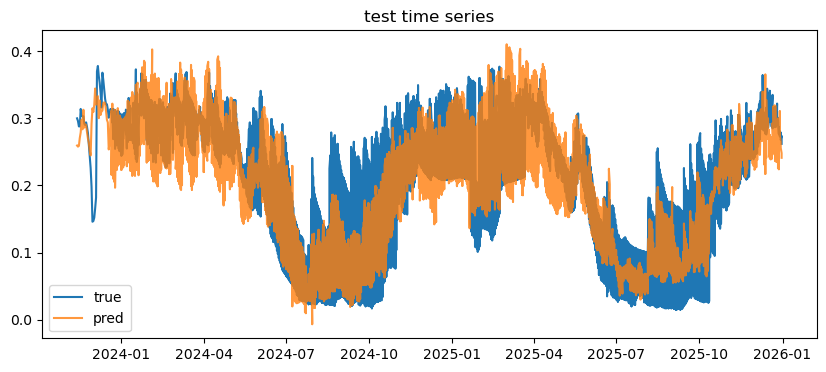

In [ ]:
dates = pd.to_datetime(test_df["date"])
order = np.argsort(dates)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates.iloc[order], y_test_true[order], label="true")
ax.plot(dates.iloc[order], y_test_pred[order], label="pred", alpha=0.8)
ax.set_title("test time series")
ax.legend()
plt.show()